In [21]:
#1.Importation des bibliotheques

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from kneed import KneeLocator
import os


In [22]:
#2. Chargement de données

project_root = os.path.dirname(os.getcwd())
df = pd.read_csv(os.path.join(project_root, "data", "processed", "marketing_campaign_cleaned.csv"))
df_pca = np.load(os.path.join(project_root, "data", "processed", "df_pca.npy"))



In [23]:
#3. Normalisation

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.select_dtypes(include='number'))

===== K-MEANS SANS ACP =====
K optimal (elbow)      : 5
K optimal (silhouette) : 2
Silhouette scores      : [0.244, 0.167, 0.168, 0.17, 0.099, 0.103, 0.151, 0.108, 0.105]


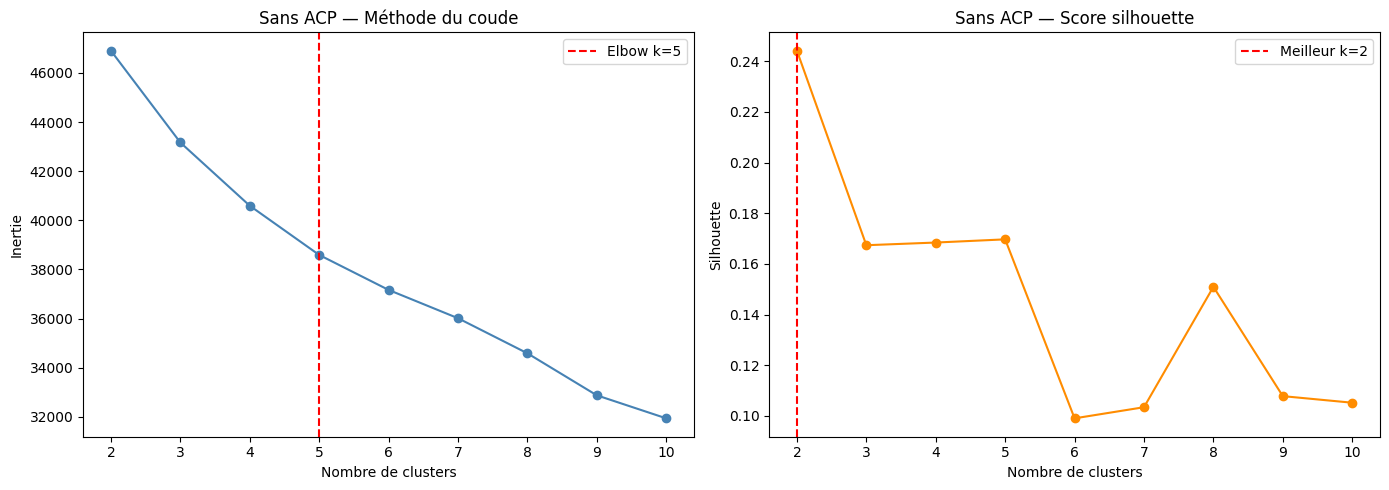

In [24]:
#4.KMEANS SANS ACP

inerties = []
silhouettes = []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_scaled)
    inerties.append(km.inertia_)
    silhouettes.append(silhouette_score(df_scaled, labels))

# Détection du coude
kneedle = KneeLocator(list(K), inerties, curve='convex', direction='decreasing')
k_elbow = kneedle.knee
k_silhouette = list(K)[np.argmax(silhouettes)]

print("===== K-MEANS SANS ACP =====")
print(f"K optimal (elbow)      : {k_elbow}")
print(f"K optimal (silhouette) : {k_silhouette}")
print(f"Silhouette scores      : {[round(s, 3) for s in silhouettes]}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inerties, marker='o', color='steelblue')
axes[0].axvline(x=k_elbow, color='red', linestyle='--', label=f'Elbow k={k_elbow}')
axes[0].set_title("Sans ACP — Méthode du coude")
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie")
axes[0].legend()

axes[1].plot(K, silhouettes, marker='o', color='darkorange')
axes[1].axvline(x=k_silhouette, color='red', linestyle='--', label=f'Meilleur k={k_silhouette}')
axes[1].set_title("Sans ACP — Score silhouette")
axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Silhouette")
axes[1].legend()
plt.tight_layout()
plt.show()


In [25]:
# Choix final du k
k_final = k_silhouette  # silhouette est prioritaire
print(f"\nK retenu : {k_final}")

# Modèle final
km_sans_acp = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df['Cluster_KMeans'] = km_sans_acp.fit_predict(df_scaled)
print(f"Répartition :\n{df['Cluster_KMeans'].value_counts()}")



K retenu : 2
Répartition :
Cluster_KMeans
0    1326
1     890
Name: count, dtype: int64


In [26]:
&epe# Visualisation 2D sans ACP (on utilise les 2 premières colonnes du dataset scalé)
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_scaled[:, 0], df_scaled[:, 1],
                      c=df['Cluster_KMeans'], cmap='Set1', alpha=0.6, s=20)
plt.colorbar(scatter)
plt.title("K-Means sans ACP — Visualisation 2D")
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (2958950735.py, line 1)

In [ ]:
#PARTIE 2 — K-MEANS AVEC ACP

inerties_pca = []
silhouettes_pca = []

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(df_pca)
    inerties_pca.append(km.inertia_)
    silhouettes_pca.append(silhouette_score(df_pca, labels))

kneedle_pca = KneeLocator(list(K), inerties_pca, curve='convex', direction='decreasing')
k_elbow_pca = kneedle_pca.knee
k_silhouette_pca = list(K)[np.argmax(silhouettes_pca)]

print("\n===== K-MEANS AVEC ACP =====")
print(f"K optimal (elbow)      : {k_elbow_pca}")
print(f"K optimal (silhouette) : {k_silhouette_pca}")
print(f"Silhouette scores      : {[round(s, 3) for s in silhouettes_pca]}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K, inerties_pca, marker='o', color='steelblue')
axes[0].axvline(x=k_elbow_pca, color='red', linestyle='--', label=f'Elbow k={k_elbow_pca}')
axes[0].set_title("Avec ACP — Méthode du coude")
axes[0].set_xlabel("Nombre de clusters")
axes[0].set_ylabel("Inertie")
axes[0].legend()

axes[1].plot(K, silhouettes_pca, marker='o', color='darkorange')
axes[1].axvline(x=k_silhouette_pca, color='red', linestyle='--', label=f'Meilleur k={k_silhouette_pca}')
axes[1].set_title("Avec ACP — Score silhouette")
axes[1].set_xlabel("Nombre de clusters")
axes[1].set_ylabel("Silhouette")
axes[1].legend()
plt.tight_layout()
plt.show()


K retenu avec ACP : 2
Répartition :
Cluster_KMeans_ACP
0    1040
1     635
2     541
Name: count, dtype: int64


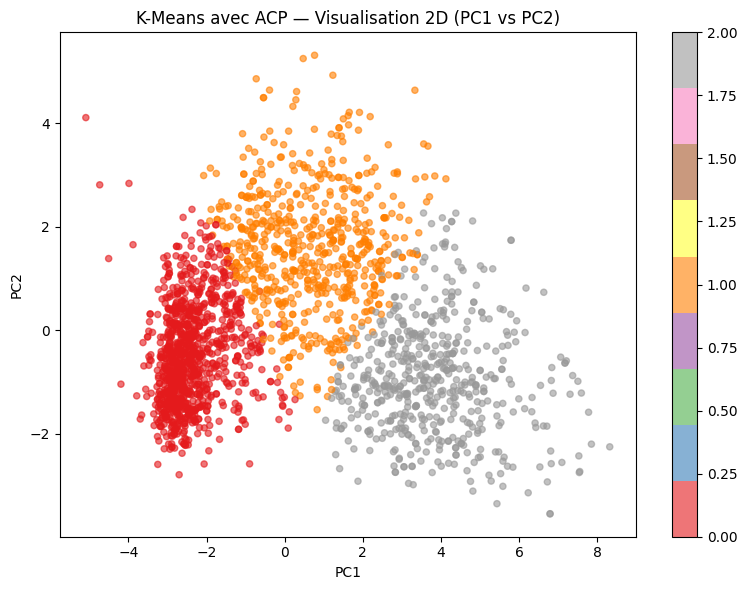

In [29]:
# Choix final du k
k_final_pca = k_silhouette_pca
print(f"\nK retenu avec ACP : {k_final_pca}")

# Modèle final
km_avec_acp = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster_KMeans_ACP'] = km_avec_acp.fit_predict(df_pca)
print(f"Répartition :\n{df['Cluster_KMeans_ACP'].value_counts()}")

# Visualisation 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_pca[:, 0], df_pca[:, 1],
                      c=df['Cluster_KMeans_ACP'], cmap='Set1', alpha=0.6, s=20)
plt.colorbar(scatter)
plt.title("K-Means avec ACP — Visualisation 2D (PC1 vs PC2)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()